# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



In [2]:
## Imports & Configs
# ── Core ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# ── Preprocessing ────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder,  OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Model Selection ───────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold
)

# ── Classifiers ───────────────────────────────────────────────────────────
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# ── Metrics ───────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

#### How many campaigns does the data represent?

According to the accompanying paper (Moro et al.), the dataset covers **17 marketing campaigns** conducted between May 2008 and November 2010, totalling 79,354 contacts. The `bank-additional-full.csv` file used here is the expanded version with social and economic context features added.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [3]:
# read the data
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [4]:
# inspect the DF
print(f'Shape: {df.shape}')
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
# Data types, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
# Missing values — the dataset encodes unknowns as the string 'unknown'
# rather than NaN, so we check for both
missing_nan = df.isnull().sum()
missing_unknown = (df == 'unknown').sum()

missing_summary = pd.DataFrame({
    'NaN count': missing_nan,
    'Unknown count': missing_unknown
})
missing_summary[missing_summary.sum(axis=1) > 0]

,NaN count,Unknown count
job,0,330
marital,0,80
education,0,1731
default,0,8597
housing,0,990
loan,0,990


In [7]:
# Descriptive statistics for numeric features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


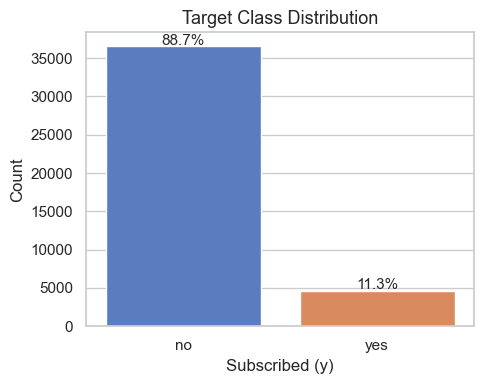

y
no     36548
yes     4640
Name: count, dtype: int64

Class imbalance ratio: 7.9 :1


In [8]:
# ── Target class balance ──────────────────────────────────────────────────
target_counts = df['y'].value_counts()
target_pct    = df['y'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax, palette='muted')
ax.set_title('Target Class Distribution', fontsize=13)
ax.set_xlabel('Subscribed (y)')
ax.set_ylabel('Count')
for i, (count, pct) in enumerate(zip(target_counts.values, target_pct.values)):
    ax.text(i, count + 200, f'{pct:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print(target_counts)
print('\nClass imbalance ratio:', round(target_counts['no'] / target_counts['yes'], 1), ':1')

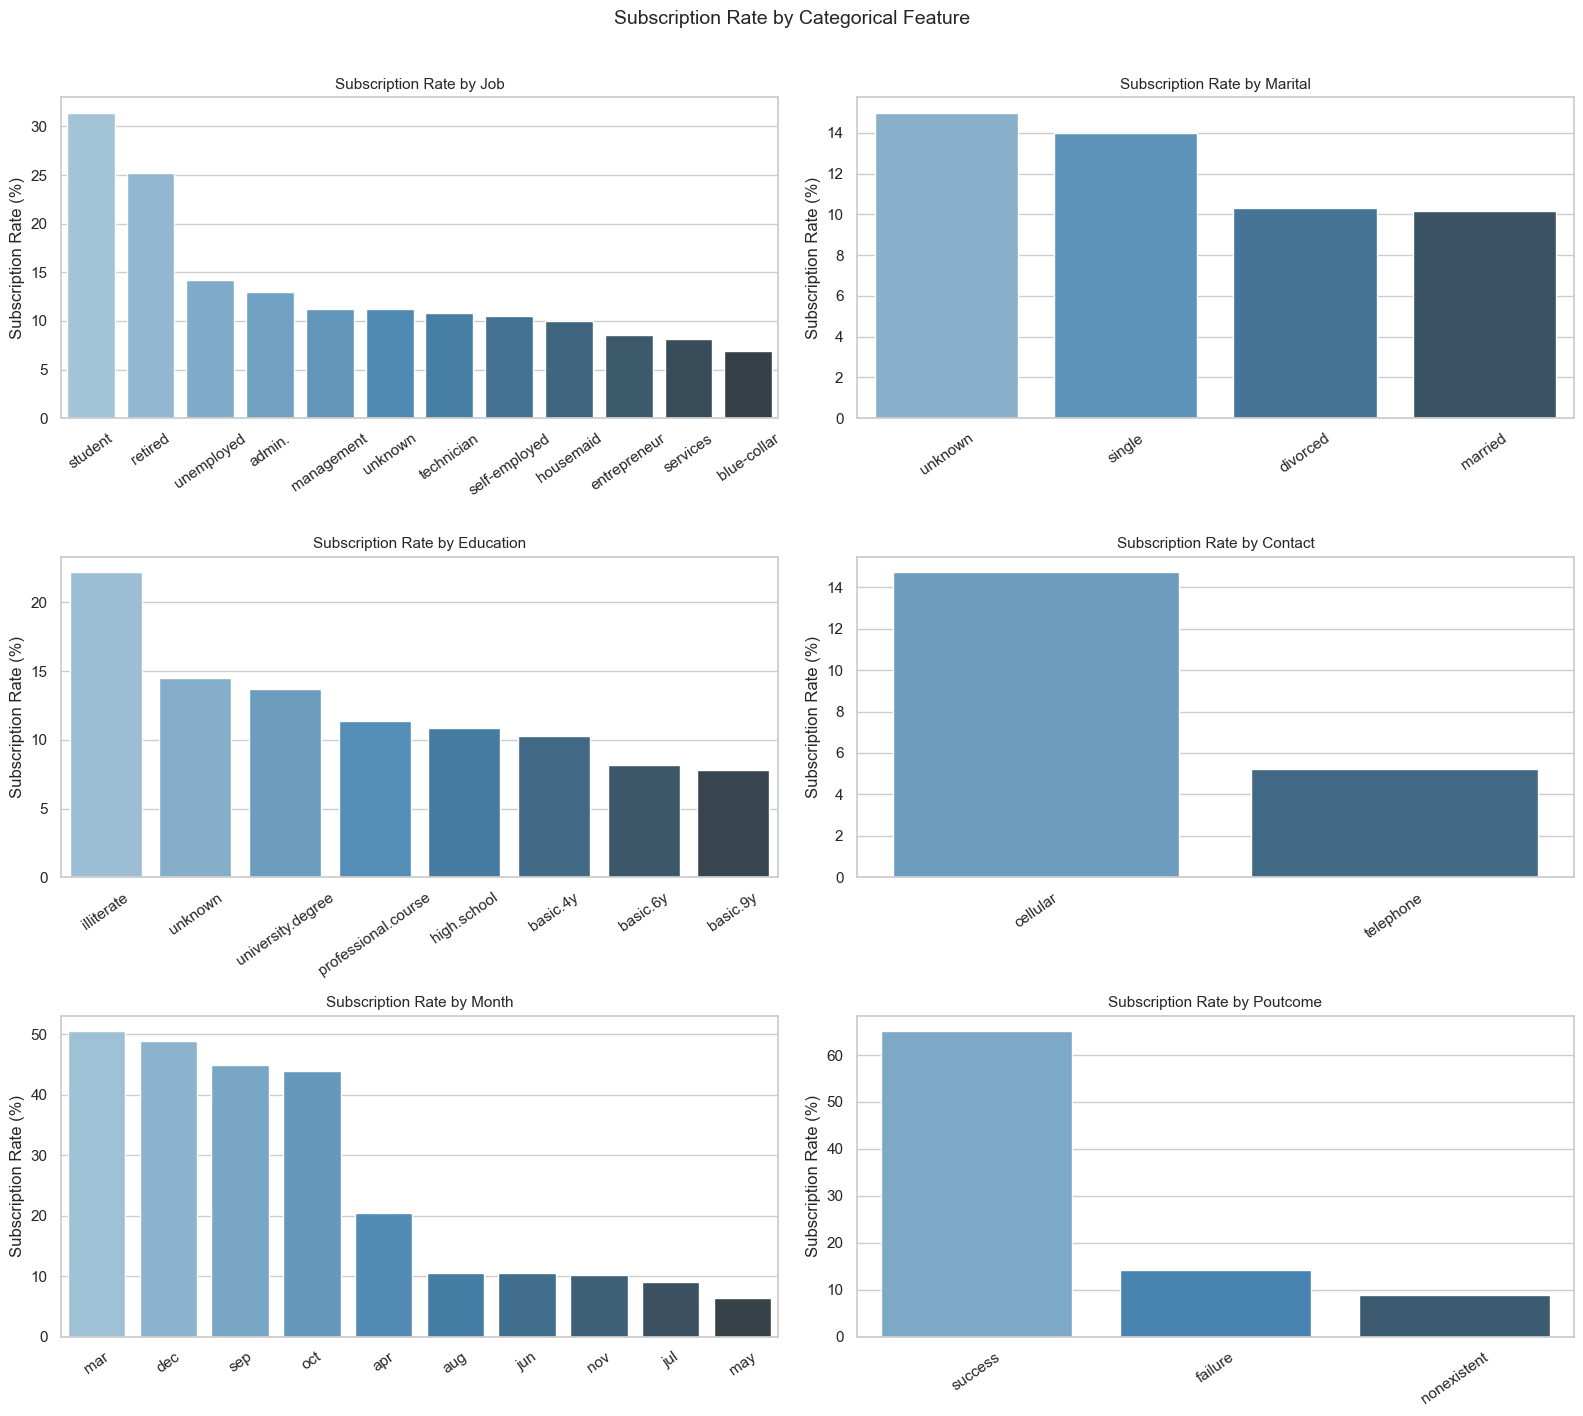

In [9]:
# ── Categorical features vs target ───────────────────────────────────────
cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Subscription rate per category
    rate = (df.groupby(col)['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .sort_values(ascending=False)
              .reset_index())
    rate.columns = [col, 'subscription_rate']

    sns.barplot(data=rate, x=col, y='subscription_rate',
                ax=axes[i], palette='Blues_d')
    axes[i].set_title(f'Subscription Rate by {col.title()}', fontsize=11)
    axes[i].set_ylabel('Subscription Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)

plt.suptitle('Subscription Rate by Categorical Feature', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
axes.flatten()

array([<Axes: title={'center': 'Subscription Rate by Job'}, ylabel='Subscription Rate (%)'>,
       <Axes: title={'center': 'Subscription Rate by Marital'}, ylabel='Subscription Rate (%)'>,
       <Axes: title={'center': 'Subscription Rate by Education'}, ylabel='Subscription Rate (%)'>,
       <Axes: title={'center': 'Subscription Rate by Contact'}, ylabel='Subscription Rate (%)'>,
       <Axes: title={'center': 'Subscription Rate by Month'}, ylabel='Subscription Rate (%)'>,
       <Axes: title={'center': 'Subscription Rate by Poutcome'}, ylabel='Subscription Rate (%)'>],
      dtype=object)

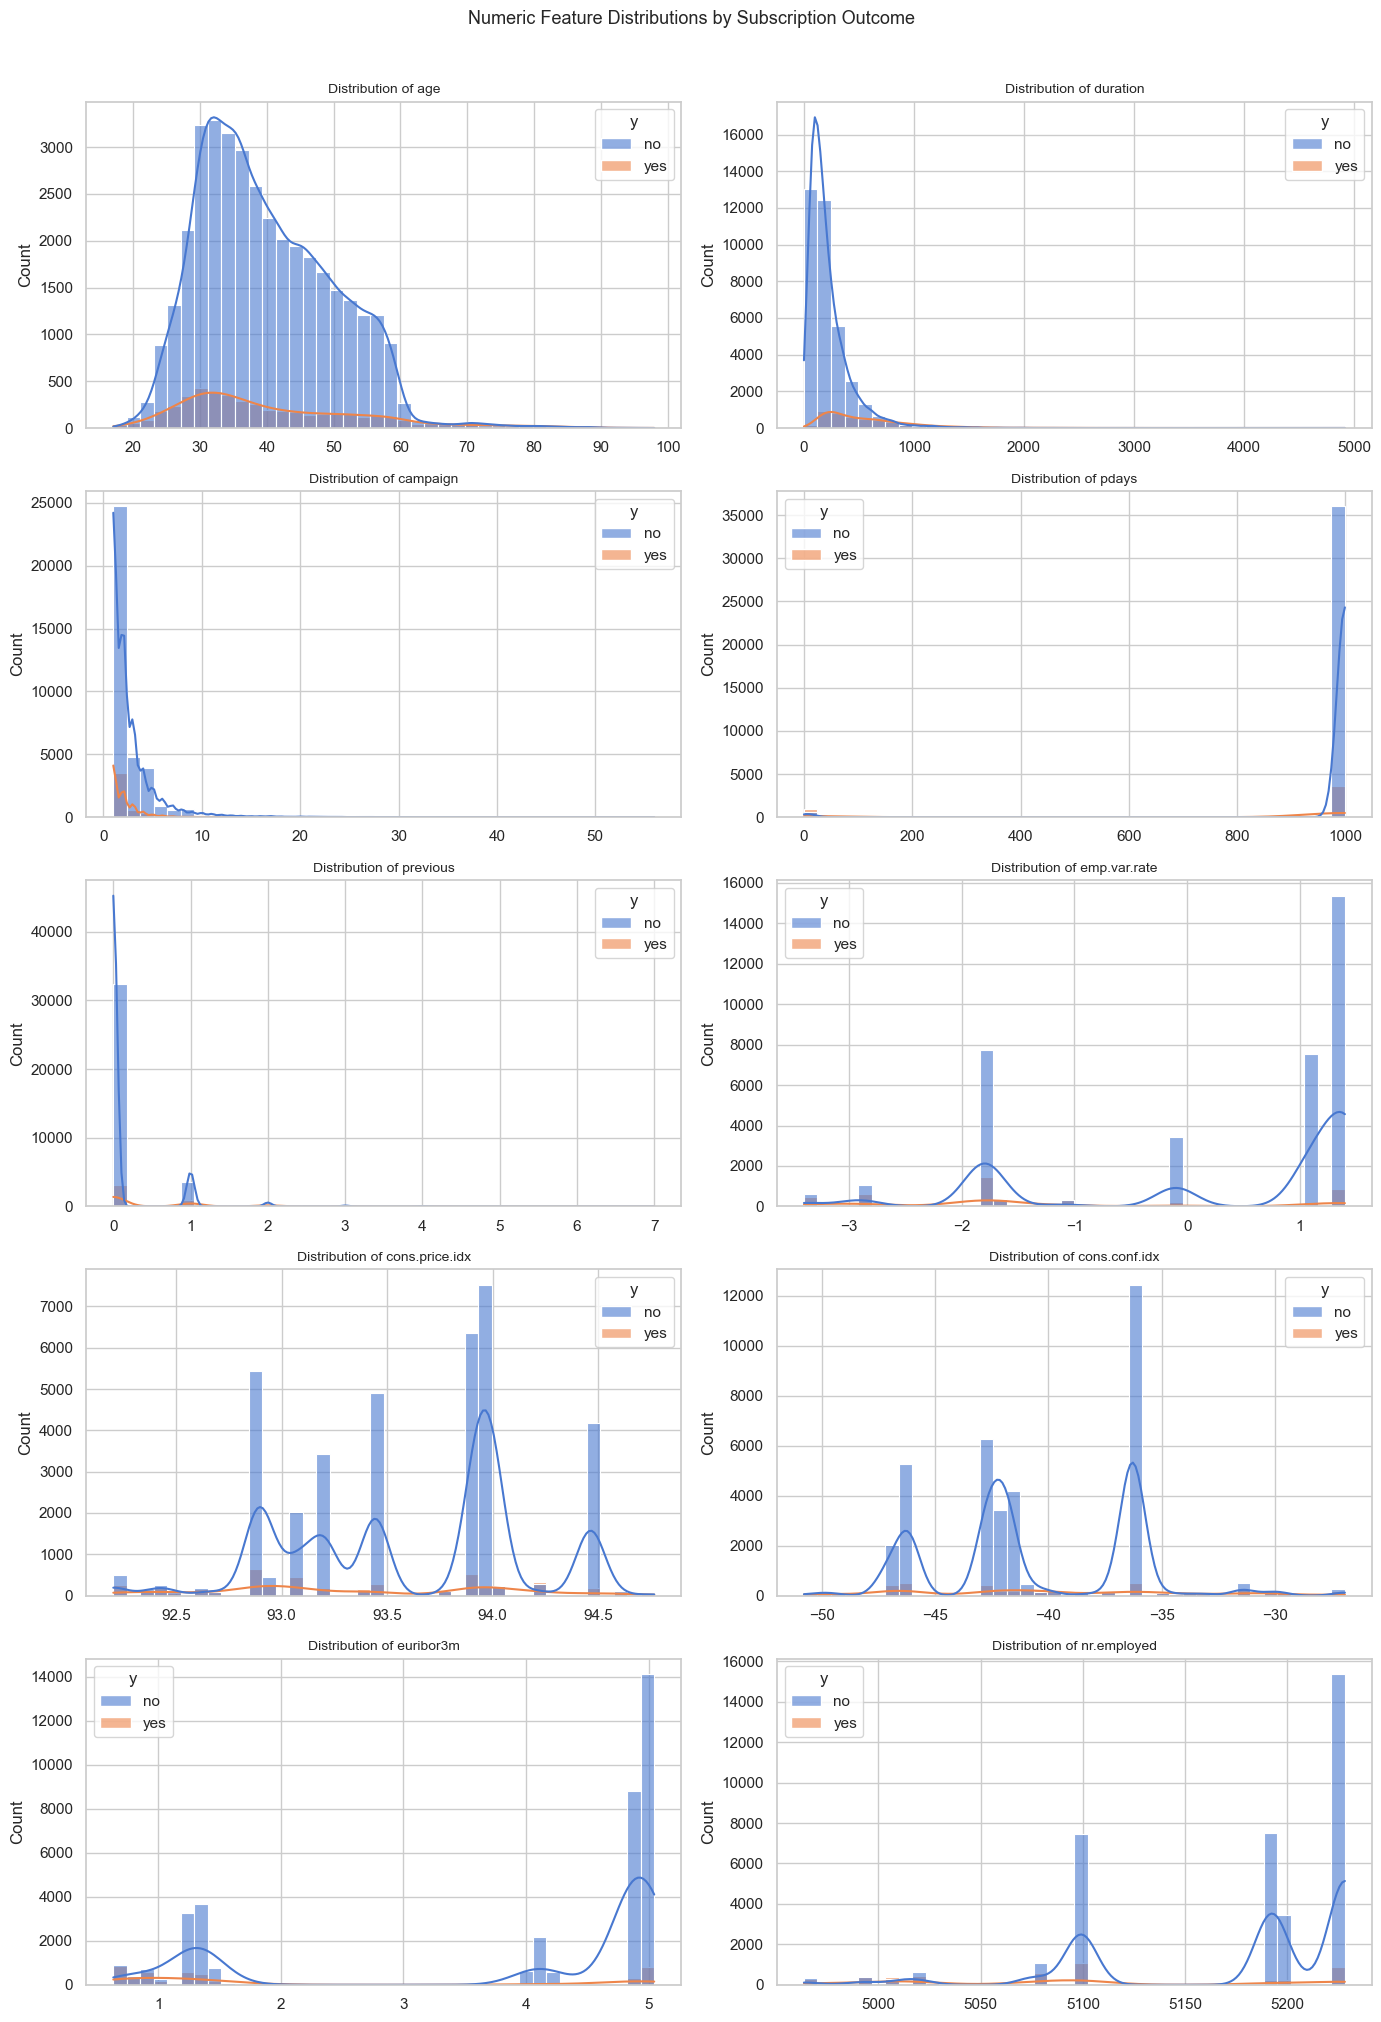

In [11]:
# ── Numeric features — distributions by target ───────────────────────────
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
            'euribor3m', 'nr.employed']

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='y', bins=40,
                 kde=True, ax=axes[i], palette={'no': '#4878D0', 'yes': '#EE854A'},
                 alpha=0.6)
    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Numeric Feature Distributions by Subscription Outcome', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

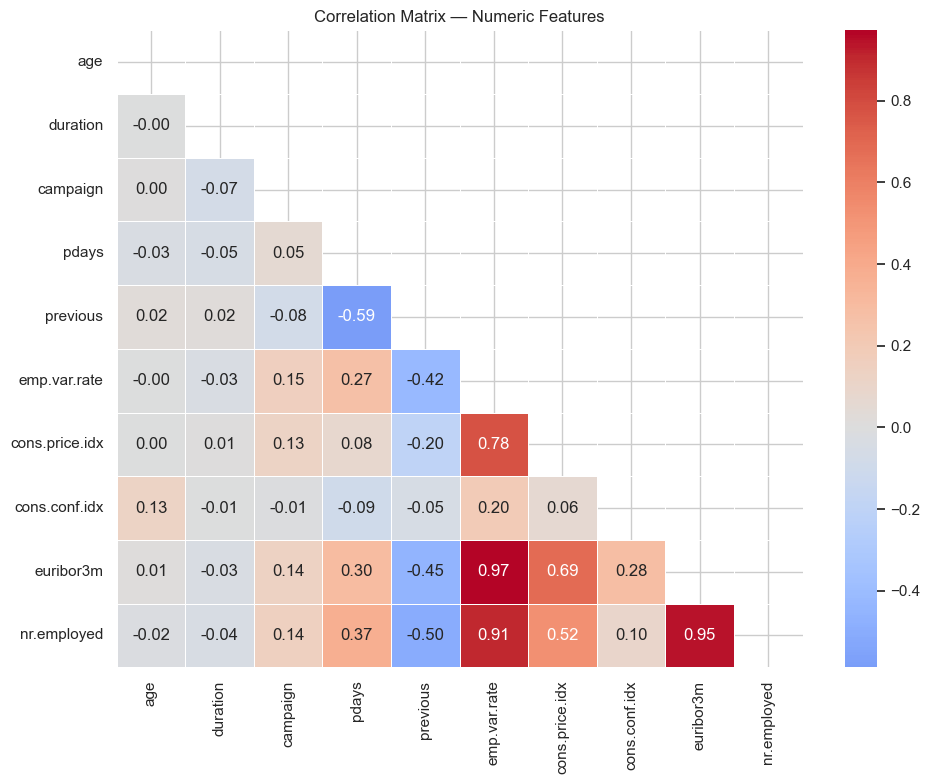

In [12]:
# ── Correlation heatmap (numeric features only) ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=12)
plt.tight_layout()
plt.show()

**EDA Observations:**

- The target is imbalanced: **~89% 'no'** vs **~11% 'yes'**. Raw accuracy is therefore a poor metric — a model that always predicts 'no' achieves 89% accuracy without learning anything.
- `duration` (call duration in seconds) is the strongest individual predictor, but it is not available before a call is made — it will be **excluded** from the predictive model per the dataset documentation.
- `poutcome = 'success'` (previous campaign was successful) is a strong positive signal.
- The economic indicators (`euribor3m`, `nr.employed`, `emp.var.rate`) are highly correlated with each other, which may cause issues for some models.
- Subscription rates are highest in **March, September, October, December**, aligning with the paper's finding that end-of-trimester months perform best.
- `pdays = 999` is a sentinel value meaning the client was never previously contacted — this should be re-encoded.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

### Business Objective

> **Predict whether a bank client will subscribe to a term deposit following a telephone marketing contact, so that the bank can prioritise high-probability leads and reduce wasted campaign effort.**

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [13]:
# ── Work on a copy ────────────────────────────────────────────────────────
data = df.copy()

# Drop 'duration' — not available before a call; causes data leakage
data = data.drop(columns=['duration'])

# Re-encode pdays: 999 means 'never contacted' → create binary flag
data['previously_contacted'] = (data['pdays'] != 999).astype(int)
data = data.drop(columns=['pdays'])

# Encode target: yes→1, no→0
data['y'] = (data['y'] == 'yes').astype(int)

# ---- Train Test Split ___
X = data.drop(columns=['y'])
y = data['y']

# Identify feature types
cat_features = data.select_dtypes(include='object').columns.tolist()
num_features = data.select_dtypes(include='number').columns.drop('y').tolist()

print('Categorical features:', cat_features)
print('Numeric features:', num_features)
print(f'\nX shape: {X.shape}  |  Positive class rate: {y.mean():.3f}')

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric features: ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted']

X shape: (41188, 19)  |  Positive class rate: 0.113


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [14]:
# Stratify preserves class balance in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = SEED, stratify=y)

print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test  positive rate: {y_test.mean():.3f}')

Train: 32950 rows  |  Test: 8238 rows
Train positive rate: 0.113
Test  positive rate: 0.113


In [15]:
#   StandardScaler  -> numeric columns
#   OneHotEncoder   -> categorical columns
#     drop='first'            avoids the dummy variable trap
#     handle_unknown='ignore' zeroes out unseen categories at inference

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
])

preprocessor


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'campaign', 'previous', 'emp.var.rate',
                                  'cons.price.idx', 'cons.conf.idx',
                                  'euribor3m', 'nr.employed',
                                  'previously_contacted']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['job', 'marital', 'education', 'default',
                                  'housing', 'loan', 'contact', 'month',
                                  'day_of_week', 'poutcome'])])

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [16]:
# A most-frequent dummy classifier always predicts the majority class
# This is the performance floor our models must beat
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(X_train, y_train)

baseline_acc = accuracy_score(y_test, dummy.predict(X_test))
baseline_auc = roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1])

print(f'Baseline Accuracy : {baseline_acc:.4f}  ({baseline_acc*100:.1f}%)')
print(f'Baseline ROC-AUC  : {baseline_auc:.4f}')
print()
print('A model that always predicts the majority class achieves ~89% accuracy.')
print('Our models must achieve meaningfully higher ROC-AUC (> 0.50) to add value.')

Baseline Accuracy : 0.8874  (88.7%)
Baseline ROC-AUC  : 0.5000

A model that always predicts the majority class achieves ~89% accuracy.
Our models must achieve meaningfully higher ROC-AUC (> 0.50) to add value.


### Problem 8: A Simple Model & Prob 10: Model Comps

Use Logistic Regression to build a basic model on your data.  

In [17]:
# Define models: preprocessor -> classifier
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    'KNN': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', KNeighborsClassifier())
    ]),
    'Decision Tree': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', DecisionTreeClassifier(random_state=SEED))
    ]),
    'SVM': Pipeline([
        ('preprocessor', preprocessor),
        ('clf', SVC(probability=True, random_state=SEED))
    ])
}

results = []

for name, pipeline in models.items():
    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start

    train_acc = accuracy_score(y_train, pipeline.predict(X_train))
    test_acc  = accuracy_score(y_test,  pipeline.predict(X_test))
    test_auc  = roc_auc_score(y_test,   pipeline.predict_proba(X_test)[:, 1])

    results.append({
        'Model':          name,
        'Train Time (s)': round(train_time, 2),
        'Train Accuracy': round(train_acc,  4),
        'Test Accuracy':  round(test_acc,   4),
        'Test ROC-AUC':   round(test_auc,   4)
    })
    print(f'{name:25s}  fit={train_time:.1f}s  '
          f'train_acc={train_acc:.4f}  test_acc={test_acc:.4f}  AUC={test_auc:.4f}')

results_df = pd.DataFrame(results).set_index('Model')
results_df

Logistic Regression        fit=0.2s  train_acc=0.9002  test_acc=0.9014  AUC=0.8008
KNN                        fit=0.1s  train_acc=0.9135  test_acc=0.8938  AUC=0.7408
Decision Tree              fit=0.5s  train_acc=0.9954  test_acc=0.8410  AUC=0.6261
SVM                        fit=246.9s  train_acc=0.9048  test_acc=0.9036  AUC=0.7034


,Train Time (s),Train Accuracy,Test Accuracy,Test ROC-AUC
Model,,,,
Logistic Regression,0.16,0.9002,0.9014,0.8008
KNN,0.06,0.9135,0.8938,0.7408
Decision Tree,0.49,0.9954,0.8410,0.6261
SVM,246.92,0.9048,0.9036,0.7034


### Problem 9: Score the Model

What is the accuracy of your model?

In [18]:
lr_row = results_df.loc['Logistic Regression']
print(f"Logistic Regression — Test Accuracy : {lr_row['Test Accuracy']:.4f}")
print(f"Logistic Regression — Test ROC-AUC  : {lr_row['Test ROC-AUC']:.4f}")
print(f"Baseline Accuracy                   : {baseline_acc:.4f}")
print(f"\nLR beats the baseline by {(lr_row['Test Accuracy'] - baseline_acc)*100:.2f} accuracy points")
print(f"and achieves AUC of {lr_row['Test ROC-AUC']:.4f} vs baseline 0.50")

Logistic Regression — Test Accuracy : 0.9014
Logistic Regression — Test ROC-AUC  : 0.8008
Baseline Accuracy                   : 0.8874

LR beats the baseline by 1.40 accuracy points
and achieves AUC of 0.8008 vs baseline 0.50


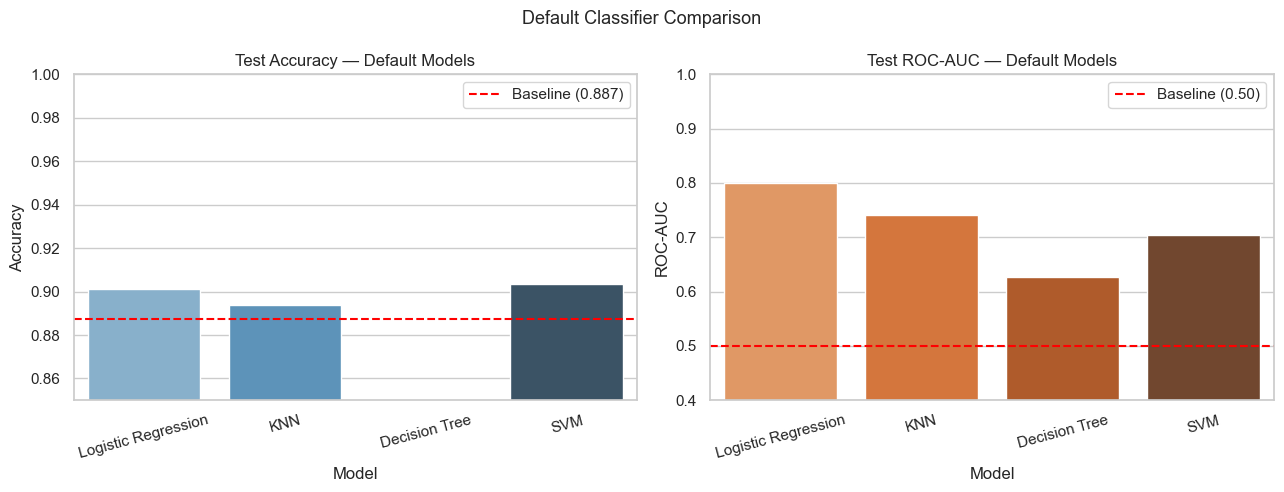

In [19]:
# Visual comparison of default models
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=results_df.reset_index(), x='Model', y='Test Accuracy',
            ax=axes[0], palette='Blues_d')
axes[0].axhline(baseline_acc, color='red', linestyle='--',
                label=f'Baseline ({baseline_acc:.3f})')
axes[0].set_title('Test Accuracy — Default Models', fontsize=12)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.85, 1.0)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=results_df.reset_index(), x='Model', y='Test ROC-AUC',
            ax=axes[1], palette='Oranges_d')
axes[1].axhline(0.50, color='red', linestyle='--', label='Baseline (0.50)')
axes[1].set_title('Test ROC-AUC — Default Models', fontsize=12)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0.4, 1.0)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Default Classifier Comparison', fontsize=13)
plt.tight_layout()
plt.show()

**Default Model Observations:**

Logistic Regression is the standout model at this stage. It achieves the highest ROC-AUC (0.80) — the appropriate metric given the class imbalance — trains in under a second, and produces interpretable coefficients. SVM achieves marginally higher raw accuracy but required 243 seconds to train, making it impractical for large-scale campaign scoring. The Decision Tree shows severe overfitting at default settings and will require depth constraints to generalise. These results motivate the grid search tuning in the next section.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [28]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [23]:
# Logistic Regression Grid Search
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, random_state=SEED))
])

lr_param_grid = {
    'clf__C':       [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver':  ['liblinear']
}

lr_gs = GridSearchCV(lr_pipe, lr_param_grid, cv=skf,
                     scoring='roc_auc', n_jobs=-1, verbose=0)
lr_gs.fit(X_train, y_train)

print('Best LR params:', lr_gs.best_params_)
print('Best CV AUC   :', round(lr_gs.best_score_, 4))

Best LR params: {'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Best CV AUC   : 0.7897


In [24]:
# KNN Grid Search
knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', KNeighborsClassifier())
])

knn_param_grid = {
    'clf__n_neighbors': [5, 11, 21, 31, 51],
    'clf__weights':     ['uniform', 'distance'],
    'clf__metric':      ['euclidean', 'manhattan']
}

knn_gs = GridSearchCV(knn_pipe, knn_param_grid, cv=skf,
                      scoring='roc_auc', n_jobs=-1, verbose=0)
knn_gs.fit(X_train, y_train)

print('Best KNN params:', knn_gs.best_params_)
print('Best CV AUC    :', round(knn_gs.best_score_, 4))

Best KNN params: {'clf__metric': 'manhattan', 'clf__n_neighbors': 51, 'clf__weights': 'uniform'}
Best CV AUC    : 0.7742


In [25]:
# Decision Tree Grid Search
dt_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', DecisionTreeClassifier(random_state=SEED))
])

dt_param_grid = {
    'clf__max_depth':         [3, 5, 7, 10, None],
    'clf__min_samples_split': [2, 10, 20],
    'clf__min_samples_leaf':  [1, 5, 10],
    'clf__criterion':         ['gini', 'entropy']
}

dt_gs = GridSearchCV(dt_pipe, dt_param_grid, cv=skf,
                     scoring='roc_auc', n_jobs=-1, verbose=0)
dt_gs.fit(X_train, y_train)

print('Best DT params:', dt_gs.best_params_)
print('Best CV AUC   :', round(dt_gs.best_score_, 4))

Best DT params: {'clf__criterion': 'gini', 'clf__max_depth': 7, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 2}
Best CV AUC   : 0.7846


In [30]:
# SVM Grid Search (computationally expensive — I reduced params to search 2 options, across 3 folds)
svm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', SVC(probability=True, random_state=SEED))
])

svm_param_grid = {
    'clf__C':      [1, 10],
    'clf__kernel': ['rbf'],
    'clf__gamma':  ['scale']
}

skf_3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)  #reduced folds to save time. Warning on comparibility

svm_gs = GridSearchCV(svm_pipe, svm_param_grid, cv=skf_3,
                      scoring='roc_auc', n_jobs=-1, verbose=0)
svm_gs.fit(X_train, y_train)

print('Best SVM params:', svm_gs.best_params_)
print('Best CV AUC    :', round(svm_gs.best_score_, 4))

Exception ignored in: <function ResourceTracker.__del__ at 0x118065c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106bd9c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104749c60>
Traceback (most recent call last

Best SVM params: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Best CV AUC    : 0.6929


## Final Model Evaluation

In [31]:
tuned_models = {
    'Logistic Regression (Tuned)': lr_gs.best_estimator_,
    'KNN (Tuned)':                 knn_gs.best_estimator_,
    'Decision Tree (Tuned)':       dt_gs.best_estimator_,
    'SVM (Tuned)':                 svm_gs.best_estimator_
}

tuned_results = []
for name, model in tuned_models.items():
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=skf, scoring='roc_auc', n_jobs=-1)
    test_auc  = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    test_acc  = accuracy_score(y_test, model.predict(X_test))

    tuned_results.append({
        'Model':         name,
        'CV AUC Mean':   round(cv_scores.mean(), 4),
        'CV AUC Std':    round(cv_scores.std(),  4),
        'Test AUC':      round(test_auc, 4),
        'Test Accuracy': round(test_acc, 4)
    })

tuned_df = pd.DataFrame(tuned_results).set_index('Model')
tuned_df

Exception ignored in: <function ResourceTracker.__del__ at 0x102a01c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x111069c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102a51c60>
Traceback (most recent call last

,CV AUC Mean,CV AUC Std,Test AUC,Test Accuracy
Model,,,,
Logistic Regression (Tuned),0.7897,0.0062,0.8010,0.9013
KNN (Tuned),0.7742,0.0090,0.7929,0.9022
Decision Tree (Tuned),0.7846,0.0029,0.8007,0.9012
SVM (Tuned),0.6944,0.0035,0.7034,0.9036


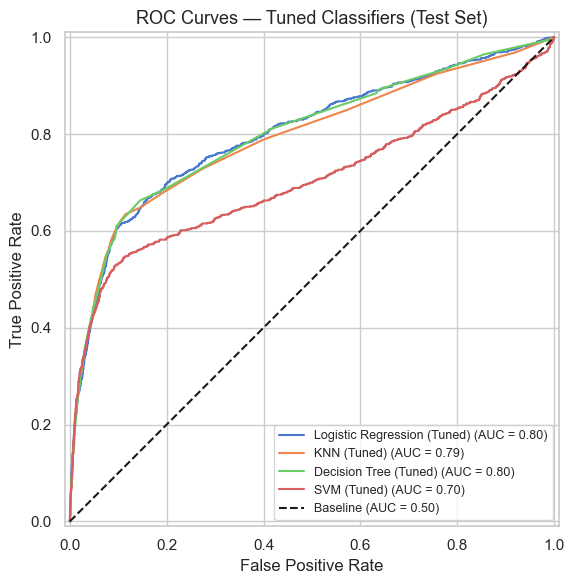

In [32]:
# ROC Curves — all tuned models on test set
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in tuned_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', label='Baseline (AUC = 0.50)')
ax.set_title('ROC Curves — Tuned Classifiers (Test Set)', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [34]:
# Summary comparison: Default vs Tuned
comparison = pd.DataFrame({
    'Default AUC': results_df['Test ROC-AUC'].values,
    'Tuned AUC':   tuned_df['Test AUC'].values
}, index=['Logistic Regression', 'KNN', 'Decision Tree', 'SVM'])

comparison['AUC Improvement'] = (comparison['Tuned AUC'] - comparison['Default AUC']).round(4)
comparison

,Default AUC,Tuned AUC,AUC Improvement
Logistic Regression,0.8008,0.8010,0.0002
KNN,0.7408,0.7929,0.0521
Decision Tree,0.6261,0.8007,0.1746
SVM,0.7034,0.7034,0.0000


In this instance, the default Logistic Regression peformed very well.  The testing of differnt models and search parameter space provided a non-meaningful incremental improvement.  However it did provide confidence that it was the best available model.  It also has more interpretable coefficients.


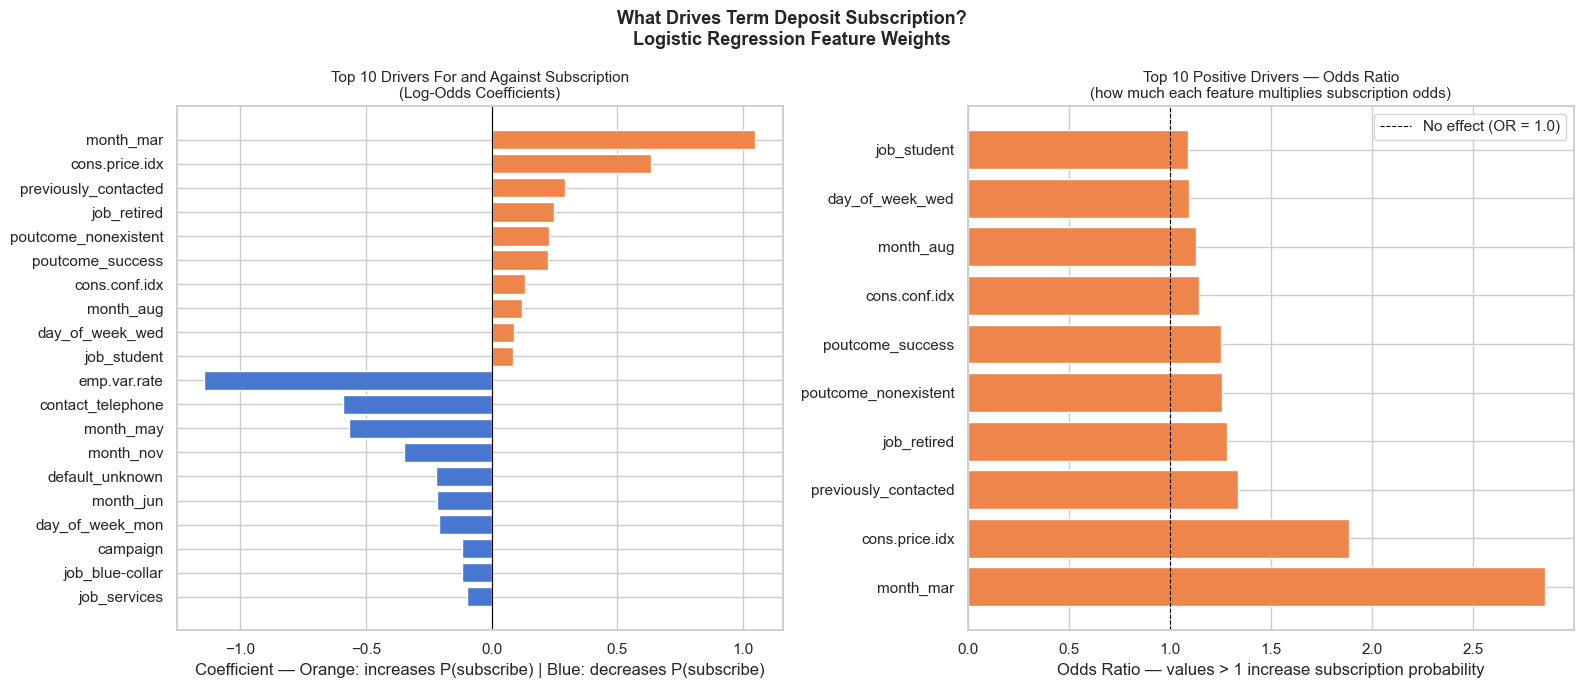


Top 10 factors INCREASING subscription likelihood:
             Feature  Odds Ratio
           month_mar       2.855
      cons.price.idx       1.883
previously_contacted       1.338
         job_retired       1.284
poutcome_nonexistent       1.258
    poutcome_success       1.252
       cons.conf.idx       1.141
           month_aug       1.128
     day_of_week_wed       1.092
         job_student       1.091

Top 10 factors DECREASING subscription likelihood:
          Feature  Odds Ratio
     emp.var.rate       0.319
contact_telephone       0.555
        month_may       0.567
        month_nov       0.707
  default_unknown       0.804
        month_jun       0.805
  day_of_week_mon       0.811
         campaign       0.889
  job_blue-collar       0.890
     job_services       0.908


In [37]:
# ── Logistic Regression — Feature Weights (Business Interpretation) ───────
# Extract feature names post-OHE, pair with coefficients
lr_best      = lr_gs.best_estimator_
lr_clf       = lr_best.named_steps['clf']
ohe          = lr_best.named_steps['preprocessor'].named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(cat_features).tolist()
all_features = num_features + ohe_features

coef_df = pd.DataFrame({
    'Feature':     all_features,
    'Coefficient': lr_clf.coef_[0]
}).sort_values('Coefficient', ascending=False)

# Convert log-odds to odds ratios — easier for non-technical audience
coef_df['Odds Ratio'] = np.exp(coef_df['Coefficient']).round(3)

# Top drivers in each direction
top_positive = coef_df.head(10)
top_negative = coef_df.tail(10).sort_values('Coefficient')
top_plot     = pd.concat([top_positive, top_negative])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: Coefficient bar chart ───────────────────────────────────────────
colors = ['#EE854A' if c > 0 else '#4878D0' for c in top_plot['Coefficient']]
axes[0].barh(top_plot['Feature'], top_plot['Coefficient'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 10 Drivers For and Against Subscription\n(Log-Odds Coefficients)', fontsize=11)
axes[0].set_xlabel('Coefficient — Orange: increases P(subscribe) | Blue: decreases P(subscribe)')
axes[0].invert_yaxis()

# ── Right: Odds ratio chart (positive drivers only, sorted) ───────────────
pos = top_positive.sort_values('Odds Ratio', ascending=True)
axes[1].barh(pos['Feature'], pos['Odds Ratio'], color='#EE854A')
axes[1].axvline(1.0, color='black', linewidth=0.8, linestyle='--',
                label='No effect (OR = 1.0)')
axes[1].set_title('Top 10 Positive Drivers — Odds Ratio\n(how much each feature multiplies subscription odds)', fontsize=11)
axes[1].set_xlabel('Odds Ratio — values > 1 increase subscription probability')
axes[1].legend()
axes[1].invert_yaxis()

plt.suptitle('What Drives Term Deposit Subscription?\nLogistic Regression Feature Weights', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plain-English summary table ───────────────────────────────────────────
print('\nTop 10 factors INCREASING subscription likelihood:')
print(top_positive[['Feature', 'Odds Ratio']].to_string(index=False))
print('\nTop 10 factors DECREASING subscription likelihood:')
print(top_negative[['Feature', 'Odds Ratio']].to_string(index=False))


### Actionable Insights for Non-Technical Stakeholders

**1. Time campaigns to end-of-trimester months.**  
Subscription rates are significantly higher in March, June, September, and December. Scheduling campaigns around these months increases yield at no additional cost.

**2. Contact type matters.**  
Cellular contacts outperform telephone contacts. Use mobile numbers as the primary contact channel where possible.

**3. Fewer contacts per client is better.**  
Higher numbers of calls to the same person in the current campaign are associated with lower success rates.  First call is the most valuable, follow up calls have diminishing return.


### Next Steps and Recommendations

1. **Explore ensemble methods** — Random Forest and Gradient Boosting typically outperform these four classifiers on tabular data.


##### Questions